In [1]:
from hybrid_joint import *
from diffrax import *
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from controls import *

In [13]:
def cholesky_2by2_matrix(a): # only use if no two brownians are fully correlated
    matrix = jnp.array([[1,a],[a,1]])
    return jax.scipy.linalg.cholesky(matrix, lower=True)

In [19]:
a = 0.5
print(cholesky_2by2_matrix(a))
print(a, jnp.sqrt(1-a**2))

[[1.        0.       ]
 [0.5       0.8660254]]
0.5 0.8660254


In [110]:
H = 0.1
M = 2
grid_points = 10000
kappa = 1
T = 1.
print(T/grid_points)

0.0001


In [195]:
def cholesky_3by3_matrix(a, b, c): # only use if no two brownians are fully correlated
    matrix = jnp.array([[1,a,b],[a,1,c],[b,c,1]])
    return jax.scipy.linalg.cholesky(matrix, lower=True)

def correlated_fbm_bm(rho, grid_points, T, H, kappa):
    pathf, pathB = hybrid_scheme(grid_points, 2, T, H, kappa)
    correlated_fbm =  rho*pathf[0,:] + jnp.sqrt(1-rho**2)*pathf[1,:]
    return correlated_fbm, pathB[0,:]

def correlated_fbm_bm_bm(rho01, rho02, rho12, grid_points, T, H, kappa):
    pathf, pathB = hybrid_scheme(grid_points, 3, T, H, kappa)
    sigma = cholesky_3by3_matrix(rho01, rho02, rho12)
    pathf_corr = jnp.dot(sigma,pathf)
    pathB_corr = jnp.dot(sigma,pathB)
    return pathf_corr[0,:], pathB_corr[1,:], pathB_corr[2,:]

In [217]:
fbm, bm1, bm2 = correlated_fbm_bm_bm(0,0.5,0.5, grid_points, T, 0.2, kappa)

(10000,)


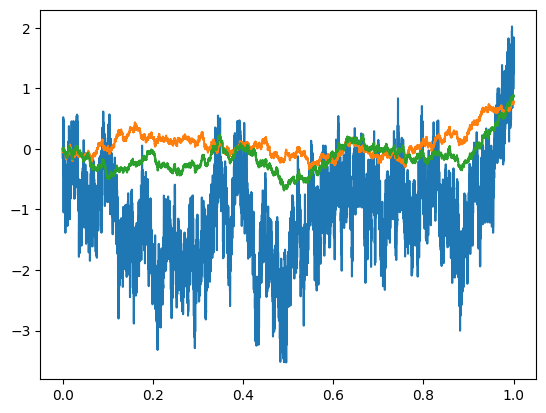

In [218]:
ts = jnp.linspace(0, T, grid_points)
print(fbm.shape)
plt.plot(ts, fbm)
plt.plot(ts, bm1)
plt.plot(ts, bm2)